# Predicting Online Purchase Intent Based on User Behavior #

##### ***Name*** : _Allen Daniel Raju_
##### ***Batch*** :  _DSML - D53_ 
##### ***Organization*** : _Entri Elevate Coding_
##### ***Date*** : _18-04-2025_

### Dataset
The dataset for this analysis is publicly available on the UCI Machine Learning Repository at the following link: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

### Objective
The objective is to use machine learning techniques to predict online purchase intent based on how users behave on the website

## Loading necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("online_shoppers_intention.csv")

In [3]:
data

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [4]:
df = pd.DataFrame(data)

## Initial Data Inspection

In [5]:
print("Initial Data Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("Data Types:\n", df.dtypes)

Initial Data Shape: (12330, 18)
Column Names: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
Data Types:
 Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [6]:
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Checking For Duplicates and Removing Them

In [8]:
duplicate = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate)
df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)

Number of Duplicate Rows: 125
Shape After Removing Duplicates: (12205, 18)


## Checking Target Variable Distribution

In [9]:
print("\nTarget Variable ('Revenue') Distribution:")
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True))


Target Variable ('Revenue') Distribution:
Revenue
False    10297
True      1908
Name: count, dtype: int64
Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64


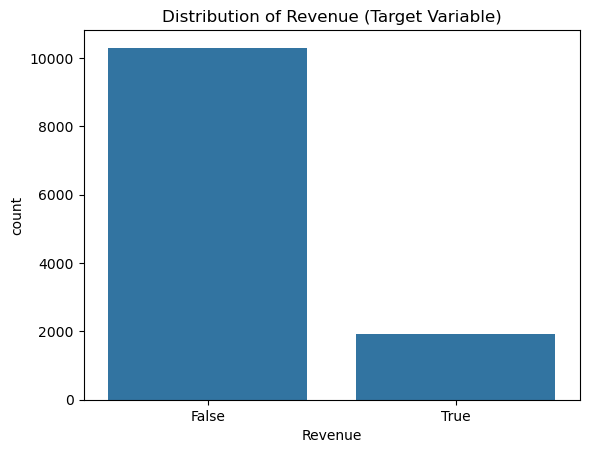

In [10]:
sns.countplot(data=df, x='Revenue')
plt.title('Distribution of Revenue (Target Variable)')
plt.show()

## Data Preprocessing and EDA

In [11]:
categorical_cols = ['Month', 'VisitorType', 'Weekend']
for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for Month:
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

Value Counts for VisitorType:
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

Value Counts for Weekend:
Weekend
False    9346
True     2859
Name: count, dtype: int64


In [12]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [13]:
numeric_features = df.select_dtypes(include = 'number')
numeric_features

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,1,1,1,1
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,1,2
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,4,1,9,3
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,3,2,2,4
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,3,3,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,4,6,1,1
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,3,2,1,8
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,3,2,1,13
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,2,2,3,11


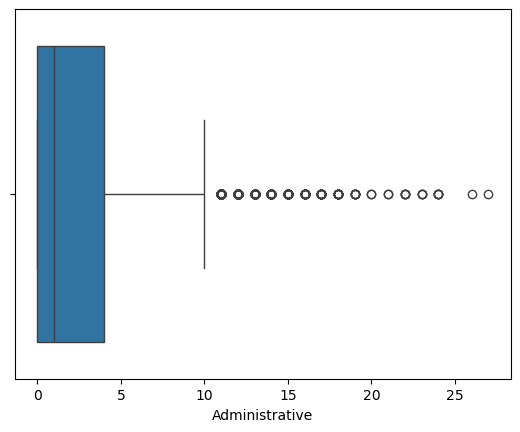

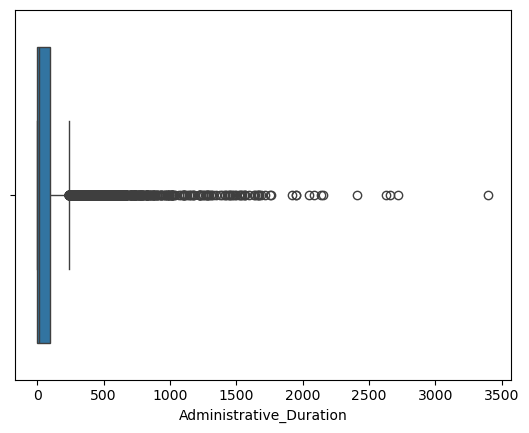

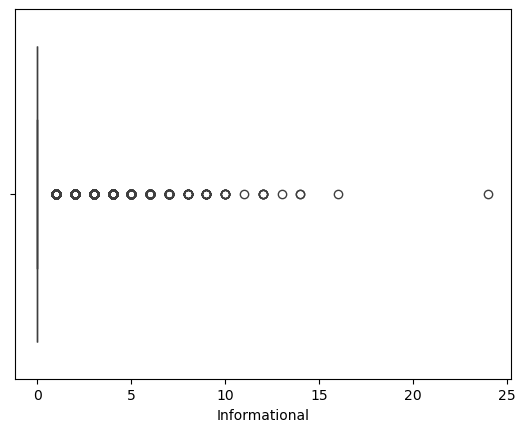

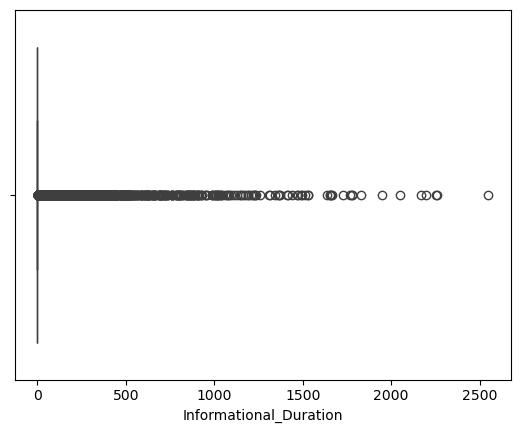

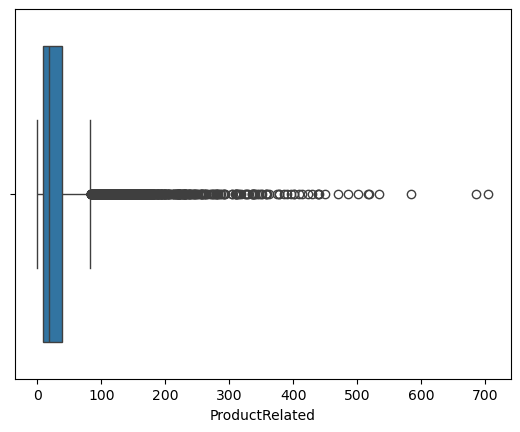

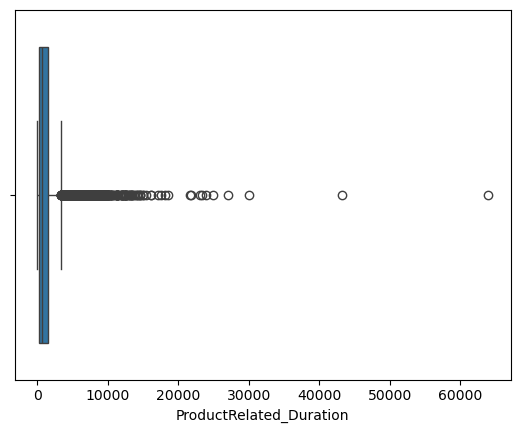

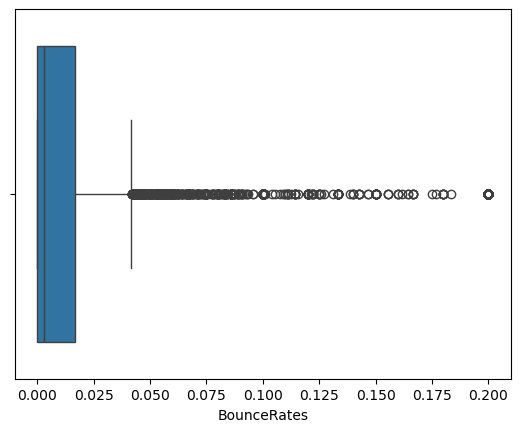

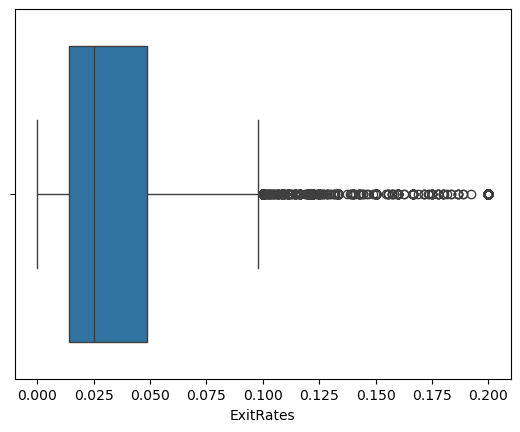

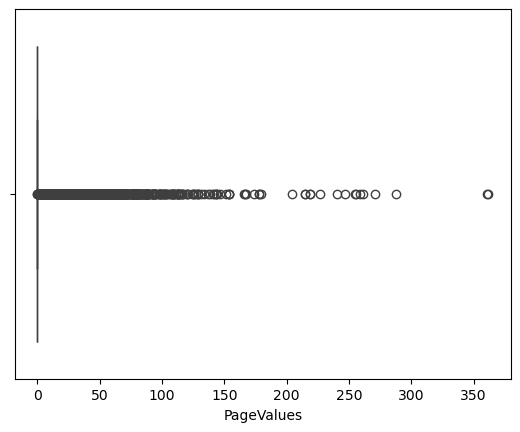

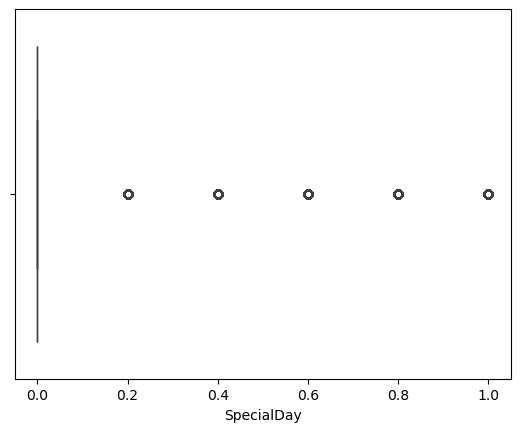

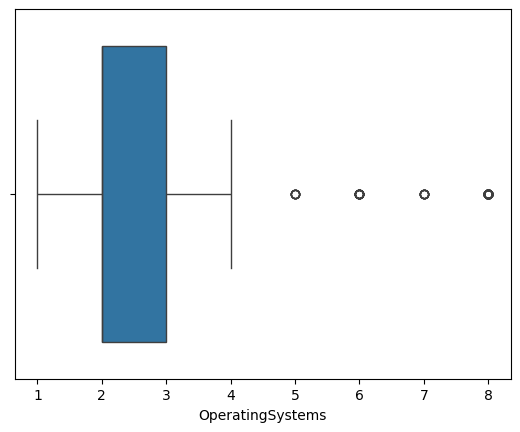

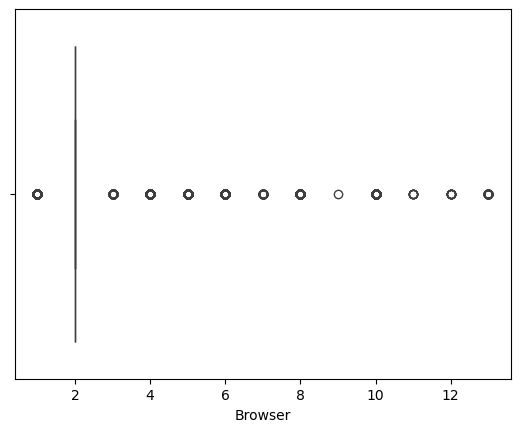

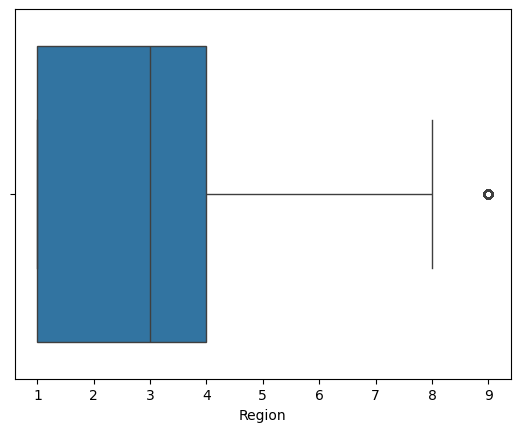

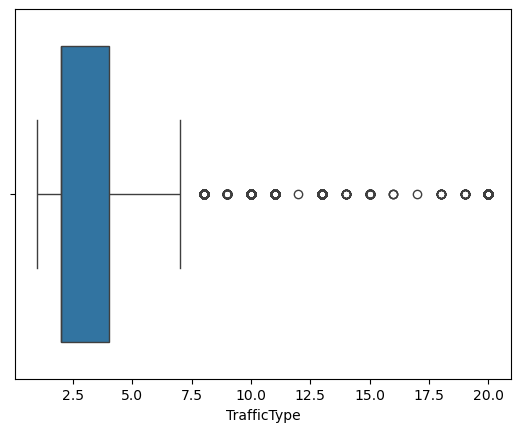

In [14]:
for i in numeric_features.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [15]:
def outliers(df):
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - (1.5 * IQR)
        upper = Q3 + (1.5 * IQR)

        #capping
        df[col] = df[col].apply(lambda x: lower if x < lower else upper if x > upper else x)

    return df

In [16]:
df = outliers(df)

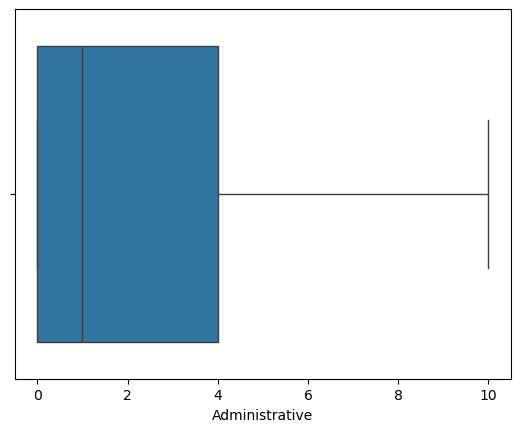

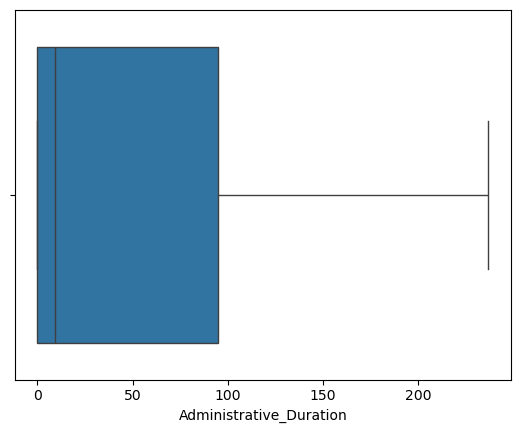

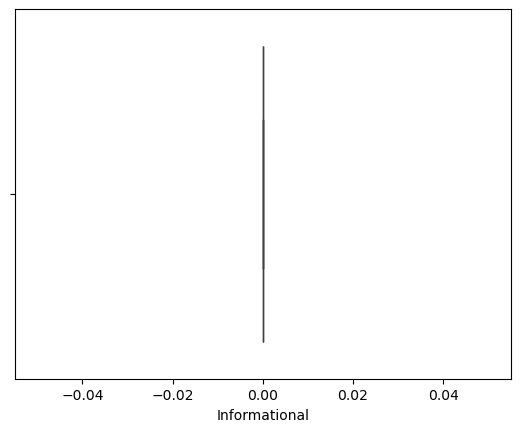

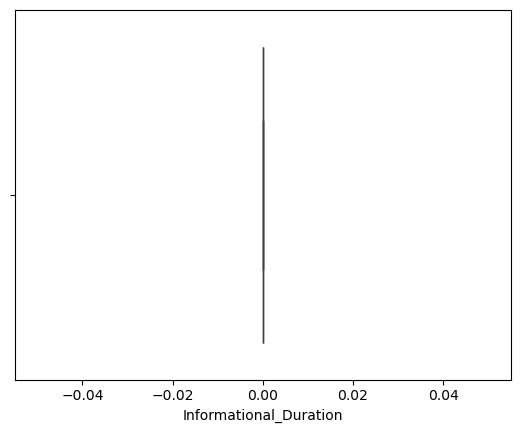

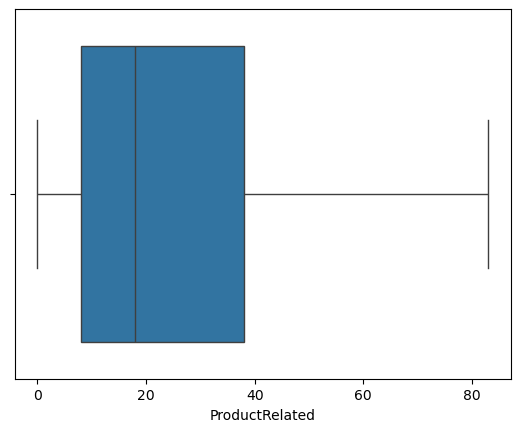

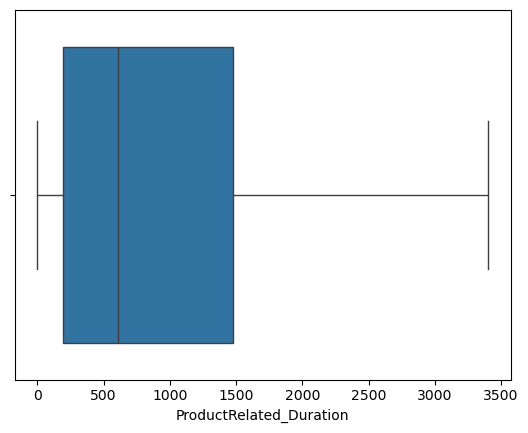

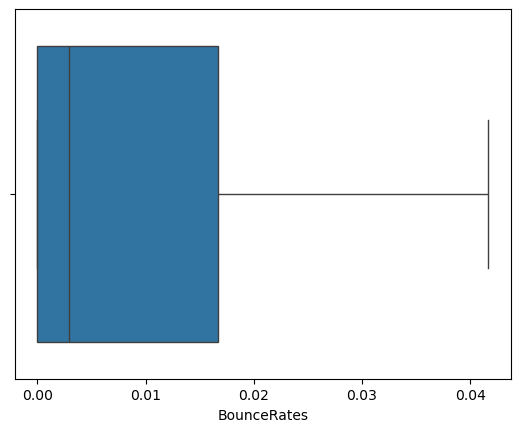

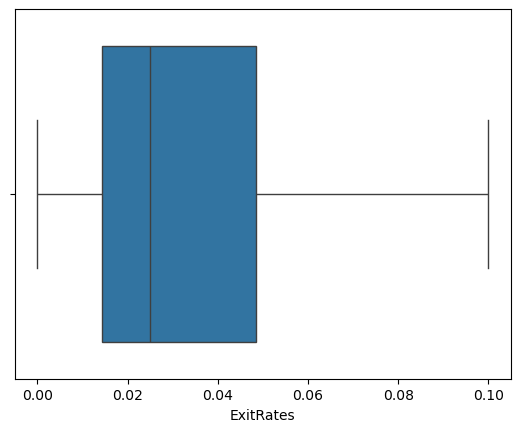

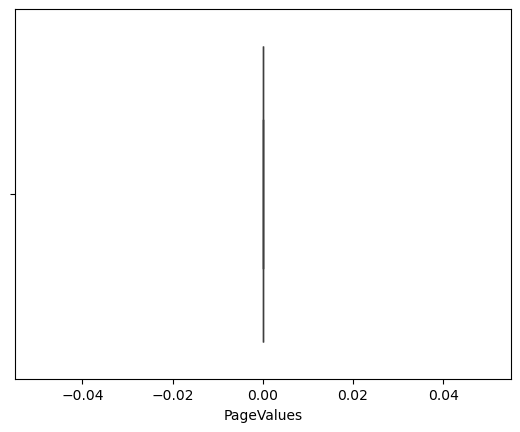

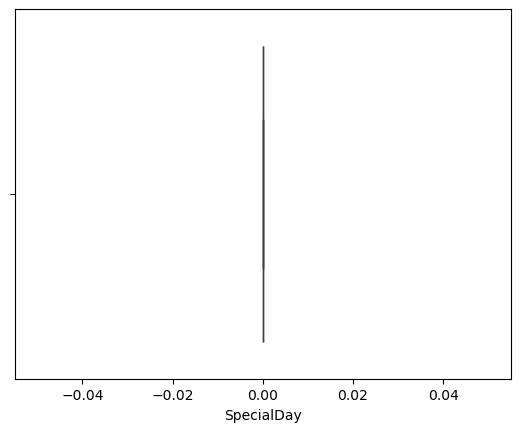

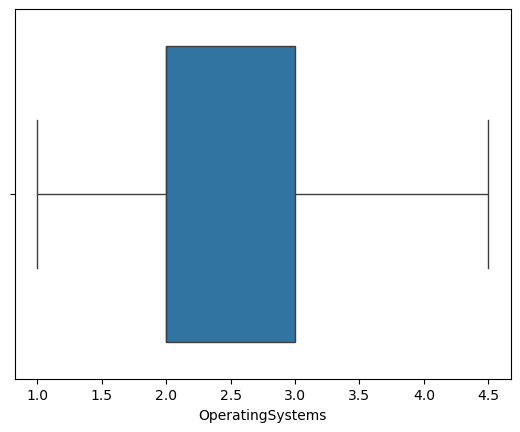

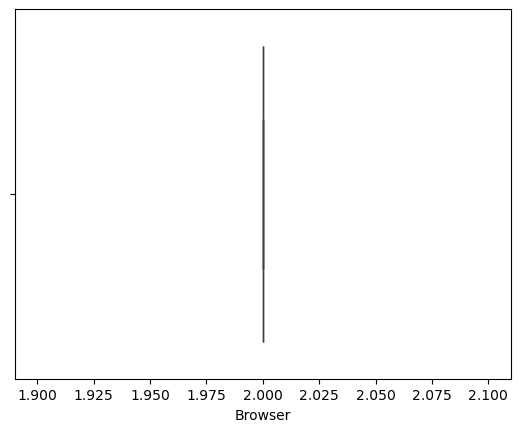

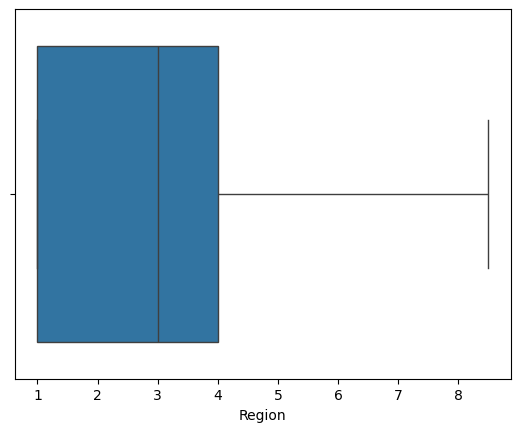

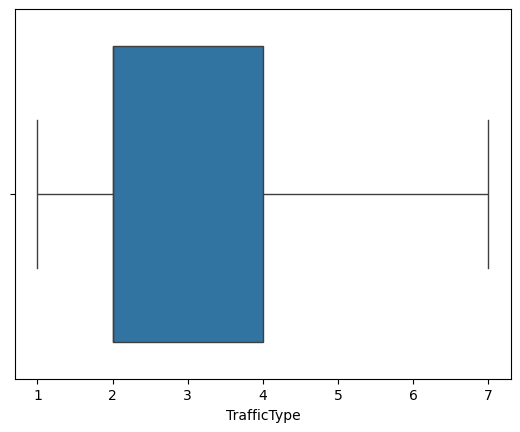

In [17]:
for i in numeric_features.columns:
    sns.boxplot(data=df,x=i)
    plt.show()

In [18]:
l = LabelEncoder()

In [19]:
df['Revenue'] = l.fit_transform(df['Revenue'])

In [20]:
df['Weekend'] = df['Weekend'].astype(int)

In [21]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.041667,0.099977,0.0,0.0,Feb,1.0,2.0,1.0,1.0,Returning_Visitor,0,0
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.000000,0.099977,0.0,0.0,Feb,2.0,2.0,1.0,2.0,Returning_Visitor,0,0
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.041667,0.099977,0.0,0.0,Feb,4.0,2.0,8.5,3.0,Returning_Visitor,0,0
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.041667,0.099977,0.0,0.0,Feb,3.0,2.0,2.0,4.0,Returning_Visitor,0,0
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.020000,0.050000,0.0,0.0,Feb,3.0,2.0,1.0,4.0,Returning_Visitor,1,0


In [22]:
df1 = pd.get_dummies(df,columns=['Month', 'VisitorType'],drop_first=True,dtype=int)

In [23]:
df1.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,0.0,0.0,1.0,0.000000,0.041667,0.099977,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0.0,0.0,0.0,0.0,2.0,64.000000,0.000000,0.099977,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.041667,0.099977,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0.0,0.0,0.0,0.0,2.0,2.666667,0.041667,0.099977,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0.0,0.0,0.0,0.0,10.0,627.500000,0.020000,0.050000,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


In [24]:
X =df1.drop('Revenue', axis=1)
y=df1['Revenue']

In [25]:
X.skew()

Administrative                    1.303703
Administrative_Duration           1.234182
Informational                     0.000000
Informational_Duration            0.000000
ProductRelated                    1.102964
ProductRelated_Duration           1.156859
BounceRates                       1.234544
ExitRates                         1.119473
PageValues                        0.000000
SpecialDay                        0.000000
OperatingSystems                  0.545422
Browser                           0.000000
Region                            0.917717
TrafficType                       0.838796
Weekend                           1.255097
Month_Dec                         2.077911
Month_Feb                         8.028813
Month_Jul                         5.029436
Month_June                        6.313340
Month_Mar                         1.934566
Month_May                         1.020578
Month_Nov                         1.190194
Month_Oct                         4.391261
Month_Sep  

In [26]:
pt =PowerTransformer(method='yeo-johnson')

In [27]:
numerical_col = X.select_dtypes(include= 'number').columns

In [28]:
df1[numerical_col] = pt.fit_transform(df1[numerical_col])
print(df1[numerical_col].skew())

Administrative                    0.223886
Administrative_Duration           0.101334
Informational                     0.000000
Informational_Duration            0.000000
ProductRelated                   -0.046414
ProductRelated_Duration          -0.156336
BounceRates                       0.568852
ExitRates                         0.255073
PageValues                        0.000000
SpecialDay                        0.000000
OperatingSystems                 -0.005492
Browser                           0.000000
Region                            0.124389
TrafficType                       0.068316
Weekend                           1.255097
Month_Dec                         2.077911
Month_Feb                         8.028813
Month_Jul                         5.029436
Month_June                        6.313340
Month_Mar                         1.934566
Month_May                         1.020578
Month_Nov                         1.190194
Month_Oct                         4.391261
Month_Sep  

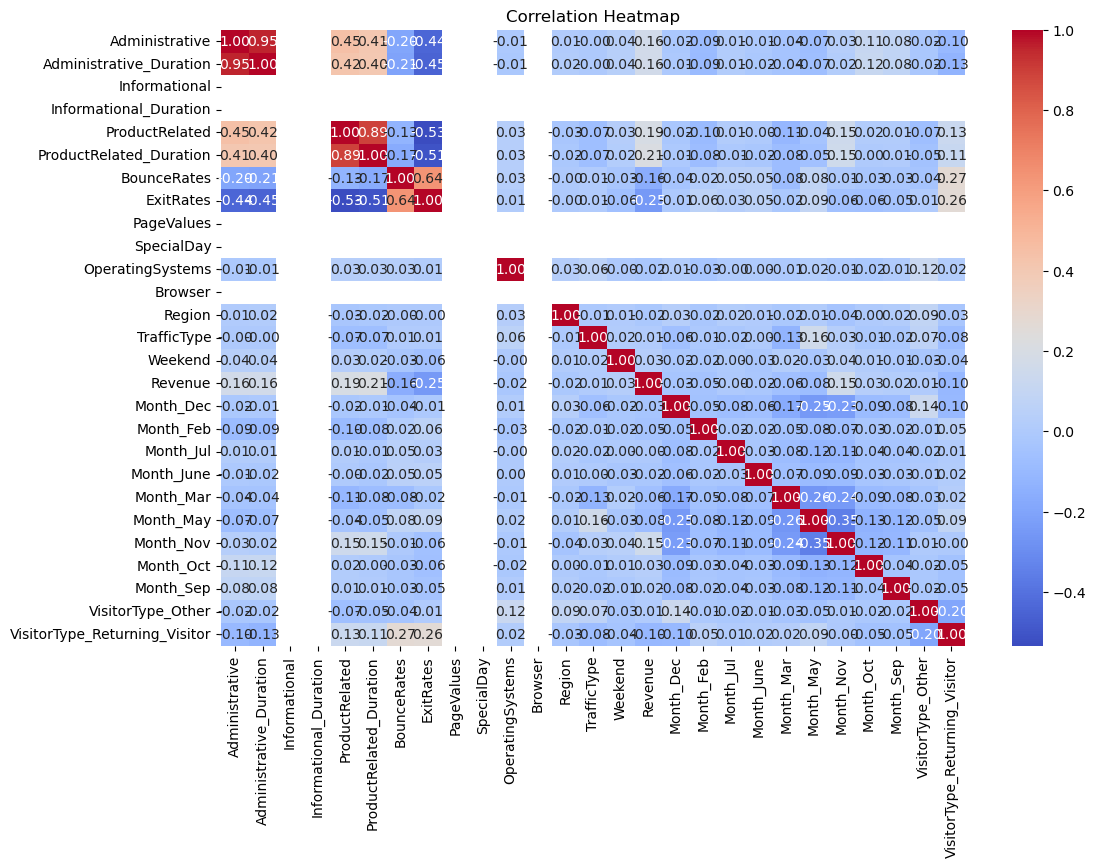

In [29]:
#Correlation Heatmp
plt.figure(figsize=(12, 8))
correlation_matrix = df1.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

This heatmap visualizes the pairwise correlation between numerical features, helping identify strong positive or negative relationships that may influence purchase intent.

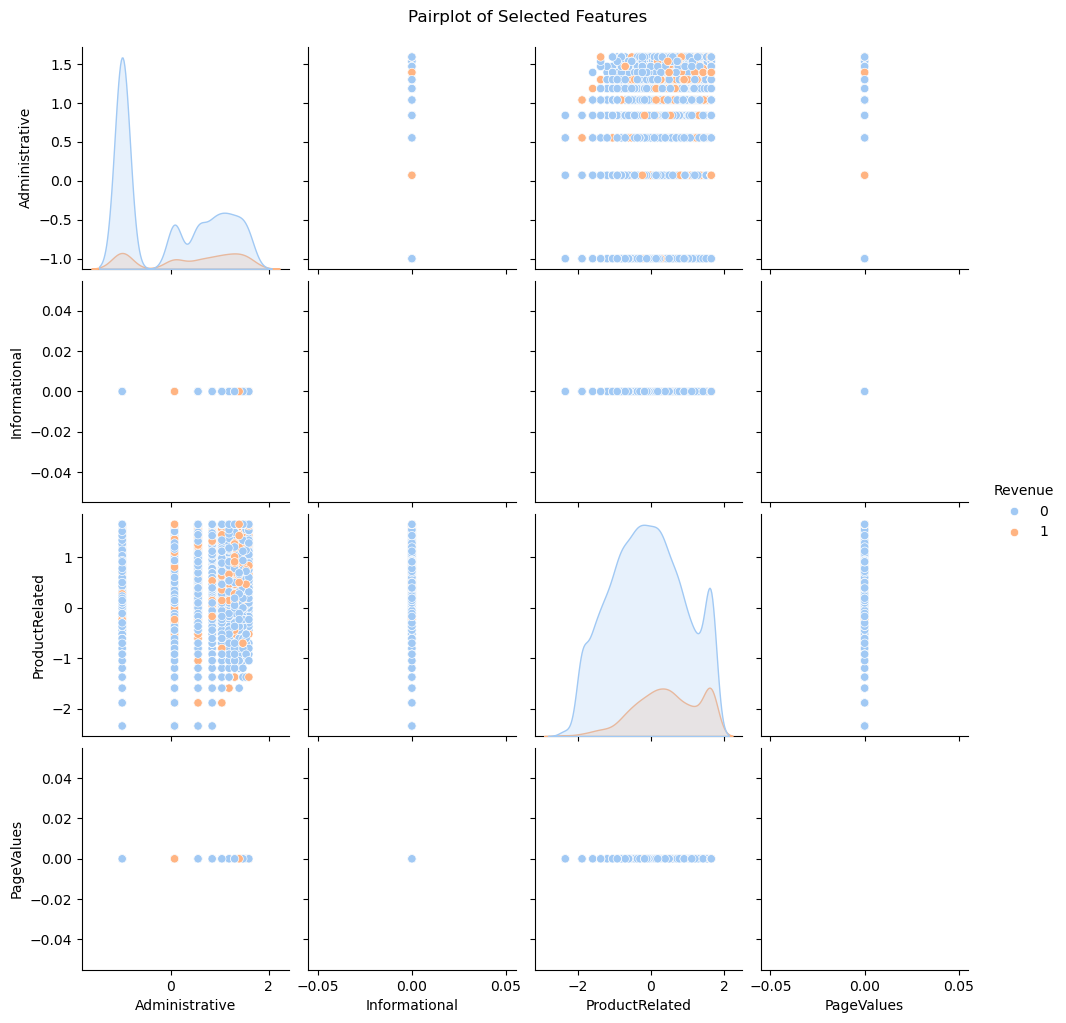

In [30]:
#Pairplot for Key Features
sns.pairplot(df1, vars=['Administrative', 'Informational', 'ProductRelated', 'PageValues'], hue='Revenue', palette='pastel')
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.show()

It shows the relationships and distribution of key user behavior features across purchase and non-purchase sessions.

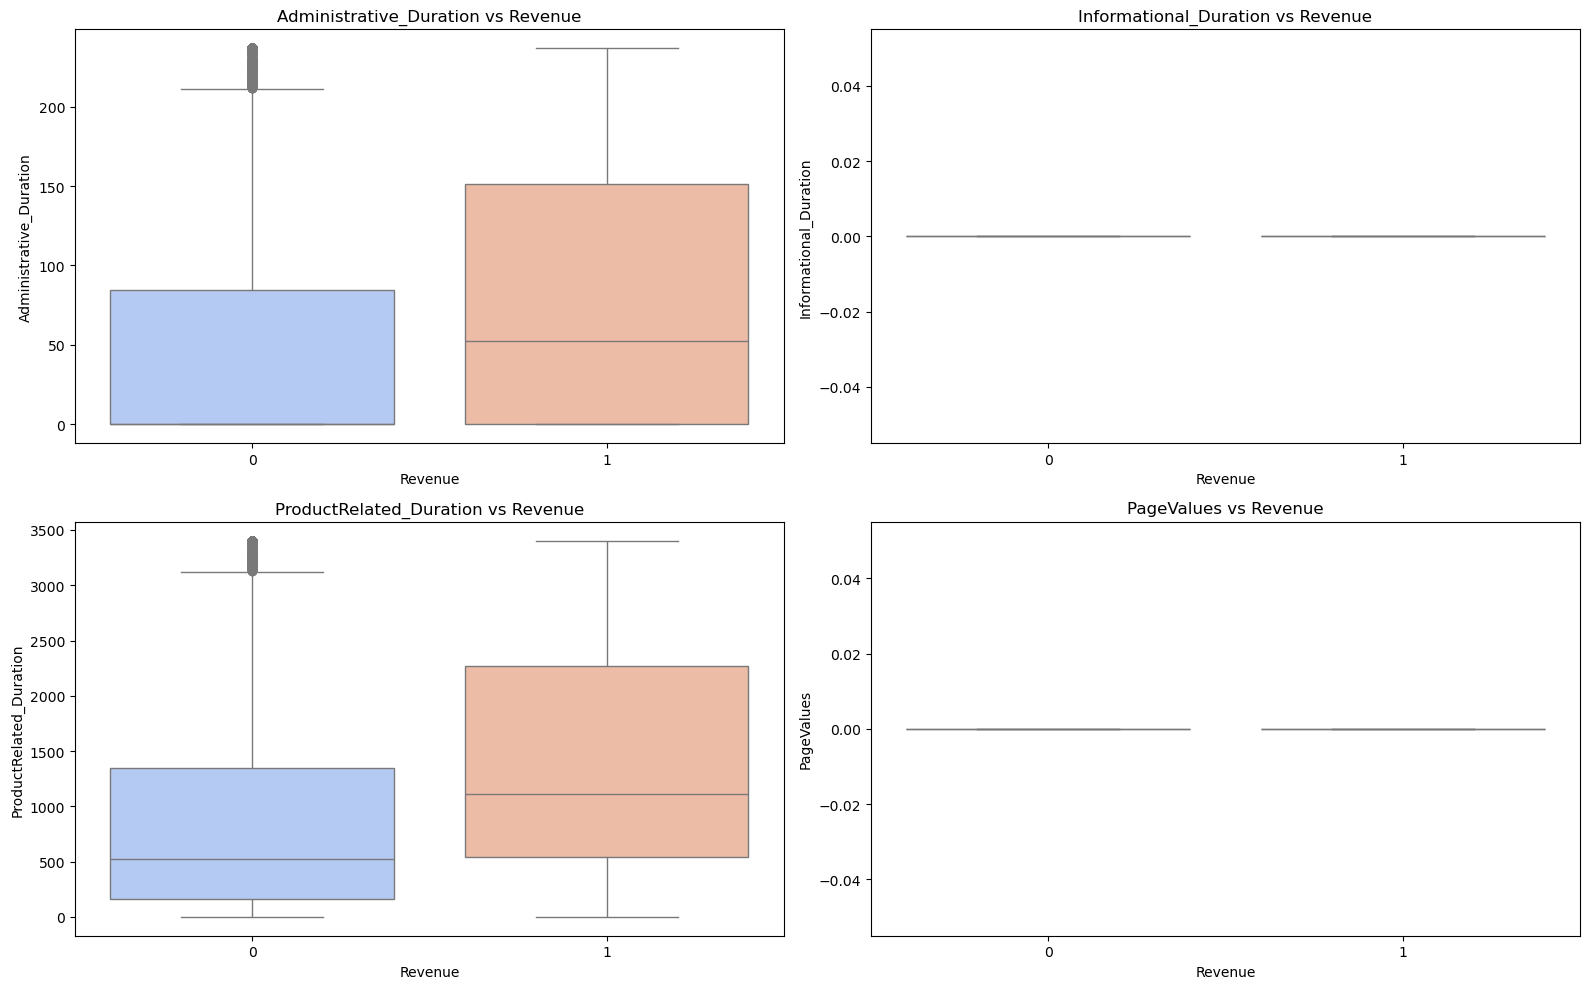

In [31]:
# Boxplots for Numeric Features vs Revenue
plt.figure(figsize=(16, 10))
numeric_features = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='Revenue', y=feature, palette='coolwarm')
    plt.title(f'{feature} vs Revenue')
plt.tight_layout()
plt.show()

These boxplots tell us how the distribution of key numeric features differs between sessions that resulted in purchases and those that didn’t, helping to detect feature importance and outliers.

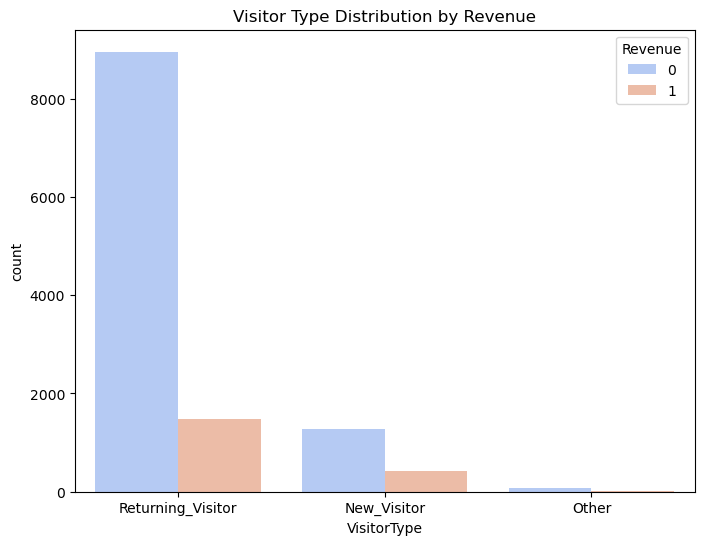

In [32]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='VisitorType', hue='Revenue', palette='coolwarm')
plt.title('Visitor Type Distribution by Revenue')
plt.show()

It compares the number of returning and new visitors with respect to their likelihood of making a purchase, highlighting the behavioral difference between user types

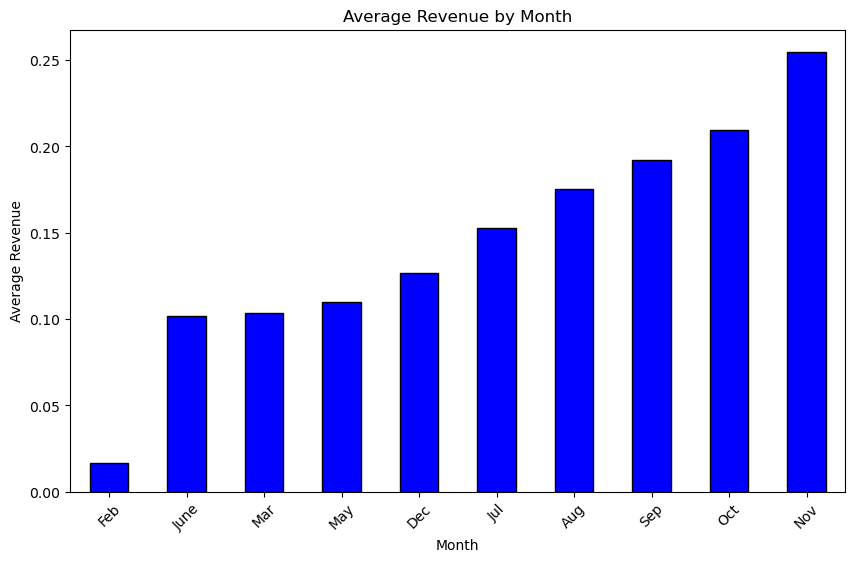

In [33]:
monthly_revenue = df.groupby('Month')['Revenue'].mean().sort_values()
plt.figure(figsize=(10, 6))
monthly_revenue.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Average Revenue by Month')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

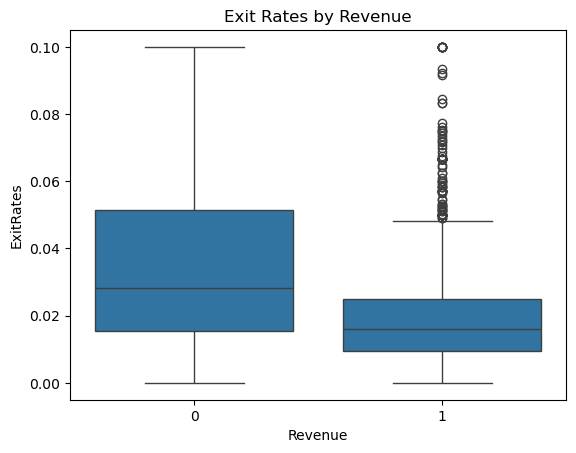

In [34]:
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("Exit Rates by Revenue")
plt.show()

This boxplot illustrates how exit rates differ between sessions that ended in purchases and those that didn’t.

## Feature Selection

In [35]:
sk = SelectKBest(score_func = f_classif, k=10 )

In [36]:
K_best = sk.fit_transform(X,y)

In [37]:
selected_features = X.columns[sk.get_support()]

In [38]:
selected_features

Index(['Administrative', 'Administrative_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'Month_Mar',
       'Month_May', 'Month_Nov', 'VisitorType_Returning_Visitor'],
      dtype='object')

In [39]:
featurescore = pd.DataFrame({
    'Feature': X.columns,
    'Score':sk.scores_}).sort_values(by='Score', ascending = False)

In [40]:
featurescore

,Feature,Score
7,ExitRates,726.345104
5,ProductRelated_Duration,447.025990
4,ProductRelated,391.140225
6,BounceRates,387.816023
21,Month_Nov,297.518900
0,Administrative,257.559127
1,Administrative_Duration,224.434043
25,VisitorType_Returning_Visitor,130.457939
20,Month_May,76.109484
19,Month_Mar,47.092929


In [41]:
X_selected = X[selected_features]

In [42]:
X_selected.columns

Index(['Administrative', 'Administrative_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'Month_Mar',
       'Month_May', 'Month_Nov', 'VisitorType_Returning_Visitor'],
      dtype='object')

In [43]:
sc =StandardScaler()

In [44]:
X_scaled = sc.fit_transform(X_selected)

## Training and Testing

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Handling Imbalance

In [46]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print("Class distribution after applying SMOTE:")
print(y_train_balanced.value_counts())

Class distribution after applying SMOTE:
Revenue
0    8218
1    8218
Name: count, dtype: int64


### Class distribution before and after smote

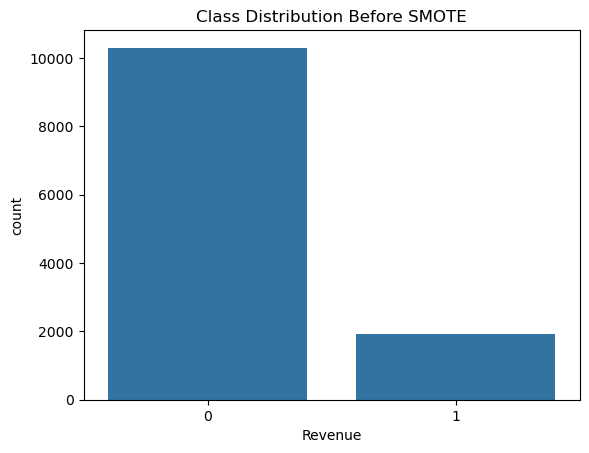

In [47]:
sns.countplot(x='Revenue', data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

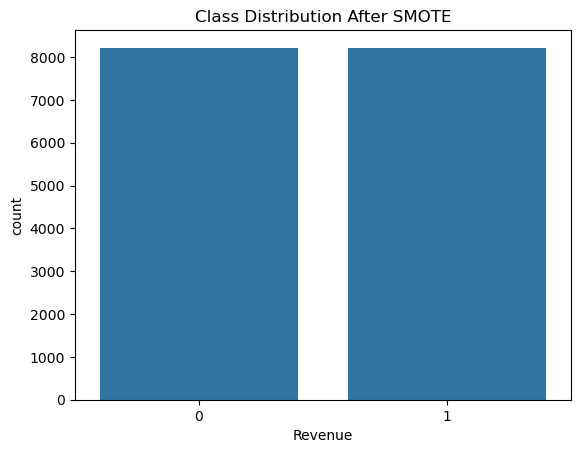

In [48]:
sns.countplot(x=y_train_balanced)
plt.title("Class Distribution After SMOTE")
plt.show()

### Converting all models into Dictionary

In [49]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),}

In [50]:
results = {}

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.6858
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      2079
           1       0.24      0.52      0.33       362

    accuracy                           0.69      2441
   macro avg       0.57      0.62      0.56      2441
weighted avg       0.80      0.69      0.73      2441

Decision Tree Accuracy: 0.7751
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      2079
           1       0.29      0.36      0.32       362

    accuracy                           0.78      2441
   macro avg       0.59      0.60      0.59      2441
weighted avg       0.80      0.78      0.78      2441

Random Forest Accuracy: 0.8378
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2079
           1       0.41      0.21      0.27       362

    accuracy                           0.84      2441
   macro avg       0.64      

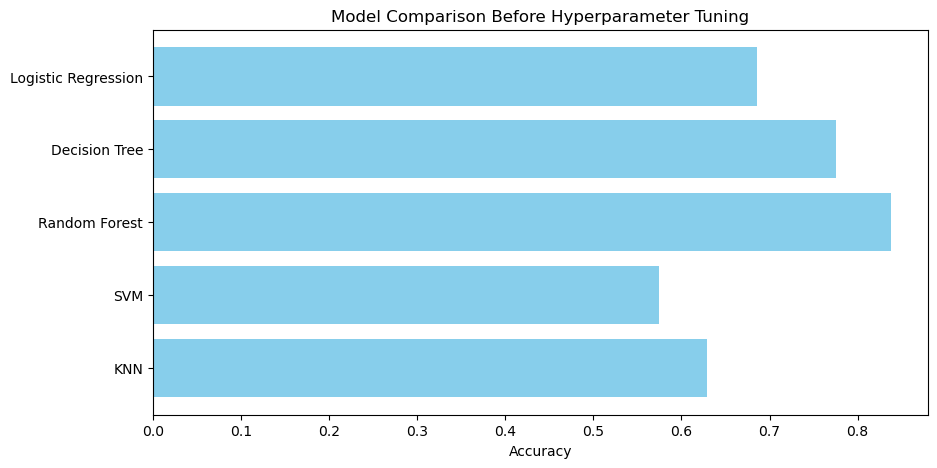

In [51]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))
plt.barh(model_names, accuracies, color='skyblue')
plt.xlabel('Accuracy')
plt.title('Model Comparison Before Hyperparameter Tuning')
plt.gca().invert_yaxis()
plt.show()

In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_balanced, y_train_balanced)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             verbose=2)

##### In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
##### On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [53]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [54]:
best_model = grid_search.best_estimator_
best_predictions = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, best_predictions)

In [55]:
print("\nModel Performance After Hyperparameter Tuning:")
print("Final Accuracy:", final_accuracy)
print("Classification Report:\n", classification_report(y_test, best_predictions))
print("Confusion Matrix:\n", confusion_matrix(y_test, best_predictions))


Model Performance After Hyperparameter Tuning:
Final Accuracy: 0.8414584186808685
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      2079
           1       0.42      0.19      0.26       362

    accuracy                           0.84      2441
   macro avg       0.65      0.57      0.59      2441
weighted avg       0.80      0.84      0.82      2441

Confusion Matrix:
 [[1985   94]
 [ 293   69]]


In [56]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),
    ('scaler', StandardScaler()),
     ('model',RandomForestClassifier())])

In [57]:
pipeline.fit(X_train_balanced, y_train_balanced)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', RandomForestClassifier())])

##### In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
##### On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [58]:
y_pred = pipeline.predict(X_test)

In [59]:
joblib.dump(pipeline, 'Purchaseintentmodel.joblib')

['Purchaseintentmodel.joblib']

In [60]:
Loaded_pipeline = joblib.load('Purchaseintentmodel.joblib')

In [61]:
X_train_balanced, X_unseen, y_train_balanced, y_unseen = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [62]:
y_pred = model.predict(X_unseen)

In [63]:
accuracy = accuracy_score(y_unseen, y_pred)
f1 = f1_score(y_unseen, y_pred)

## Output Results

In [64]:
print("Model Performance on Unseen Data")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Model Performance on Unseen Data
Accuracy: 0.7448
F1 Score: 0.5091


## Conclusion

The objective of this project is to predict online purchase intent using user behavior features using supervised machine learning techniques. By analyzing behavioral factors such as page views, session time, bounce rate, and visitor type, different models were trained to predict whether a user would make a purchase. The model's performance was initially affected by the class imbalance in identifying genuine purchases. SMOTE was used to oversample the minority class to get rid of this problem.

The final model achieved an accuracy of 84.06% on the validation data and demonstrated a better capacity for detecting purchase behavior, with an F1-score of 0.26 for the purchase class. When tested on unseen data, the model achieved 74.48% accuracy and an F1-score of 0.5091, indicating improved generalization and better handling of the minority class in real-world conditions. These results demonstrate that user behavioral features, when carefully modeled and balanced, can be effectively used to predict purchase intent.